In [1]:
%pip install \
  "sentence-transformers==3.2.1" \
  "transformers==4.45.2" \
  "huggingface_hub==0.25.2" \
  "tokenizers==0.20.3" \
  "accelerate==1.0.1" \
  "safetensors==0.4.5" \
  matplotlib \
  nltk \
  statsmodels \
  seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import re
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize, word_tokenize
import numpy as np
from time import time
from huggingface_hub import login
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import statsmodels.api as sm
import ast
import os

/Users/mathieu/anaconda3/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
[nltk_data] Downloading package punkt to /Users/mathieu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### la partie 0 peut être ignorée si la base de données brute des échanges de la FOCM n'a pas été chargée dans le dossier donnees, on peut utiliser directement le fichier qui a été obtenu par travail de Mistral

## partie 0 : DATA & MODEL

In [ ]:
chemin_fichier = "donnees/FOMC_statements_characteristics_050525.csv"
df=pd.read_csv(chemin_fichier)

on part de 142972 statements et 358 meetings

In [ ]:
df["Statement"] = df["Statement"].fillna("").astype(str)

#on enlève les @action car ils ne sont pas bien pris en compte par le modele
df["Statement"] = df["Statement"].apply(lambda x: re.sub(r"@\w+", "", x).strip())
df["Statement"] = df["Statement"].apply(lambda x: re.sub(r"\[.*?\]", "", x).strip())

#on garde que les membres de la FOCM, cela revient à exclure le staff
df = df[df["Member"] == "M"].copy()

In [ ]:
df_speaker = df[['Date', 'Speaker', 'Statement', 'Member']].copy()

### on réduit ensuite les prises de paroles à une seule par personne, la plus longue

In [ ]:
#colonne contenant la longueur du statement
df_speaker['Statement_length'] = df_speaker['Statement'].str.len()

#pour chaque individu on garde seulement sa déclaration la plus longue
df_speaker = df_speaker.loc[df_speaker.groupby(['Date', 'Speaker'])['Statement_length'].idxmax()].reset_index(drop=True)

minilm_tokenizer = SentenceTransformer('all-MiniLM-L6-v2')._first_module().tokenizer
df_speaker['token_count'] = df_speaker['Statement'].apply(lambda x: len(minilm_tokenizer.tokenize(x)))

In [5]:
#pour l'importation sur git, on peut ne pas l'utiliser et directement charger le token avec login("hf_...")
from dotenv import load_dotenv
load_dotenv()  # charge .env

ModuleNotFoundError: No module named 'dotenv'

In [ ]:
#pour se connecter à hugging face et importer mistral
#si le token n'est plus valide il faut en créer un autre et copier coller le lien dans le login
login(token=os.getenv("HF_TOKEN"))


In [ ]:
#on utilise MISTRAL-7B-Instruct-v0.2
#il y'a une v0.3 disponible mais non compatible avec l'environnement python actuel

summarizer = pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.2",
    device_map={"": 0},
    torch_dtype=torch.float16
)

def summarize_statement(text):
    token_count = len(minilm_tokenizer.tokenize(text))
    
    # Si déjà ≤ 512 tokens, on garde tel quel
    if token_count <= 512:
        return text

    # Sinon, résumé avec prompt instruct
    prompt = f"<s>[INST] Reformulate the following text as if it had been spoken by a person during a meeting. Keep the output under 512 tokens : {text} [/INST]"

    try:
        output = summarizer(prompt, max_new_tokens=512, do_sample=False)[0]["generated_text"]
        summary = output.split("[/INST]")[-1].strip()
        summary_token_count = len(minilm_tokenizer.tokenize(summary))

        if summary_token_count > 512:
            summary = " ".join(summary.split()[:512])
        
        return summary
    
    #on interrompt pas le process, il y'aura à la place du résumé écrit [ERROR]
    #ça arrive avec onyxia si la phrase à résumer est trop longue car la mémoire est déjà quasi saturée avec le téléchargement de mistral
    except Exception as e:
        print(f"Error summarizing: {e}")
        return "[ERROR]"

In [ ]:
# Application à df_speaker avec barre de progression
df_finalred = df_speaker.copy()
df_finalred["Statement"] = [
    summarize_statement(text) for text in tqdm(df_finalred["Statement"], desc="Summarizing")
]

# Sauvegarde
#df_finalred.to_csv("df_finalred.csv", index=False)
#print("Résumés sauvegardés dans df_finalred.csv")

## partie 1 : EMBEDDING ET MESURES

### etape1 : calcul de l'embedding de chacune des phrases

In [7]:
##si on veut travailler avec SBERT
#model = SentenceTransformer('all-MiniLM-L6-v2')

##si on veut travailler avec SBERT finetuné
model = SentenceTransformer("finetuned-minilm-similarity-epoch5")

##si on veut travailler avec GTE
#model = SentenceTransformer("thenlper/gte-small")

You try to use a model that was created with version 5.0.0, however, your version is 3.2.1. This might cause unexpected behavior or errors. In that case, try to update to the latest version.





In [3]:
chemin_fichier = "donnees/df_ENTIERrésuméMistral.csv"
df_finalred=pd.read_csv(chemin_fichier)
df_finalred=df_finalred[['Date','Speaker','Statement']]
#df_finalred['tokenred_count'] = df_finalred['Statement'].apply(lambda x: len(minilm_tokenizer.tokenize(x)))
df_finalred

,Date,Speaker,Statement
0,1976-03-29,MR. BALLES,"Mr. Chairman, may I respond to Governor Coldwe..."
1,1976-03-29,MR. BLACK,You also have more constraint on your federal ...
2,1976-03-29,MR. BURNS,"During our last Committee meeting, Governor Co..."
3,1976-03-29,MR. COLDWELL,"If I could, Mr. Chairman, I’d like us to retur..."
4,1976-03-29,MR. EASTBURN,"Yes, a better relationship between nonborrowed..."
...,...,...,...
6472,2018-12-19,MS. BRAINARD,"During our meeting today, I'd like to address ..."
6473,2018-12-19,MS. DALY,"During our meeting today, I'd like to begin by..."
6474,2018-12-19,MS. GEORGE,"During our meeting, I'd like to share some ins..."
6475,2018-12-19,MS. LOGAN,"At the meeting today, I'd like to discuss mone..."


In [8]:
tqdm.pandas(desc="Computing embeddings")
df_finalred["embedding"] = df_finalred["Statement"].progress_apply(lambda x: model.encode(x, show_progress_bar=False).tolist())

Computing embeddings: 100%|██████████| 6477/6477 [02:03<00:00, 52.64it/s]


In [9]:
def cosine_sim(vec1, vec2):
    return cosine_similarity([vec1], [vec2])[0][0]

In [10]:
def compute_influence_from_df(df_speaker):
    import numpy as np

    df = df_speaker.copy()
    df["influence"] = np.nan
    df["fs"] = np.nan
    df["bs"] = np.nan

    # Récupérer les dates dans l'ordre chronologique
    unique_dates = sorted(df["Date"].unique())

    # S'assurer qu'il y a au moins 3 dates pour pouvoir calculer quelque chose
    if len(unique_dates) < 3:
        raise ValueError("Il doit y avoir au moins 3 dates distinctes dans df_speaker")

    # Parcourir toutes les dates sauf la première et la dernière
    for i in range(1, len(unique_dates) - 1):
        date_before = unique_dates[i - 1]
        date_middle = unique_dates[i]
        date_after = unique_dates[i + 1]

        df_before = df[df["Date"] == date_before]
        df_middle = df[df["Date"] == date_middle]
        df_after = df[df["Date"] == date_after]

        emb_before = list(df_before["embedding"])
        emb_after = list(df_after["embedding"])

        for idx, row in df_middle.iterrows():
            vec = row["embedding"]

            fs = np.mean([cosine_sim(vec, ea) for ea in emb_after])
            bs = np.mean([cosine_sim(vec, eb) for eb in emb_before])

            influence = fs / bs if bs != 0 else float("inf")

            df.at[idx, "fs"] = fs
            df.at[idx, "bs"] = bs
            df.at[idx, "influence"] = influence

    return df

In [11]:
df_compare=compute_influence_from_df(df_finalred)

### etape2 : affichage des résultats

In [12]:
##SANS FILTRAGE
# Recalcul propre sans utiliser la colonne "influence" du DataFrame initial
df_mean_scores = (
    df_compare
    .dropna(subset=["fs", "bs"])
    .groupby("Speaker", as_index=False)[["fs", "bs"]]
    .mean()
    .rename(columns={"fs": "FS", "bs": "BS"})
)

# Recalcul de l'influence après la moyenne
df_mean_scores["Influence"] = df_mean_scores["FS"] / df_mean_scores["BS"]

# Tri pour top 12 influence
top_influence = (
    df_mean_scores.sort_values(by="Influence", ascending=False)
    .head(12)
    .reset_index(drop=True)
    .rename(columns={"Speaker": "Top Influence Speaker"})
)

# Tri pour top 12 FS
top_fs = (
    df_mean_scores.sort_values(by="FS", ascending=False)
    .head(12)
    .reset_index(drop=True)
    .rename(columns={"Speaker": "Top FS Speaker"})
)

# Tri pour top 12 BS
top_bs = (
    df_mean_scores.sort_values(by="BS", ascending=False)
    .head(12)
    .reset_index(drop=True)
    .rename(columns={"Speaker": "Top BS Speaker"})
)

# Concaténation en tableau final
top_combined = pd.concat([top_influence, top_fs, top_bs], axis=1)
top_combined


,Top Influence Speaker,FS,BS,Influence,Top FS Speaker,FS,BS,Influence,Top BS Speaker,FS,BS,Influence
0,MR. HOLLAND,0.355970,0.242565,1.467523,MR. MULLINIX,0.487886,0.439465,1.110180,MS. DALY,0.431903,0.492761,0.876497
1,MR. SAPENARO,0.200920,0.150471,1.335274,MR. GOULD,0.465698,0.455440,1.022522,MR. OLTMAN,0.460037,0.471971,0.974714
2,MR. MORIARTY,0.461286,0.365306,1.262739,MR. MORIARTY,0.461286,0.365306,1.262739,MR. STONE,0.449568,0.471043,0.954409
3,MR. CZERWINSKI,0.180306,0.155022,1.163104,MR. OLTMAN,0.460037,0.471971,0.974714,MR. GOULD,0.465698,0.455440,1.022522
4,MR. GRIFFITH,0.298186,0.260614,1.144170,MR. STONE,0.449568,0.471043,0.954409,MR. BARKIN,0.439022,0.448201,0.979520
5,MR. VARVEL,0.331914,0.292951,1.133003,MS. CUMMING,0.448306,0.432591,1.036327,MS. PHILLIPS,0.439473,0.440441,0.997802
6,MR. MULLINIX,0.487886,0.439465,1.110180,MS. PHILLIPS,0.439473,0.440441,0.997802,MR. MULLINIX,0.487886,0.439465,1.110180
7,MR. PRICHARD,0.395789,0.360994,1.096386,MR. BARKIN,0.439022,0.448201,0.979520,MR. BOSTIC,0.428497,0.436627,0.981381
8,MR. MONHOLLON,0.412794,0.381339,1.082487,MR. CLARIDA,0.433190,0.429693,1.008139,MR. GEITHNER,0.430394,0.434249,0.991122
9,MR. MACDONALD,0.408429,0.381586,1.070348,MS. DALY,0.431903,0.492761,0.876497,MS. CUMMING,0.448306,0.432591,1.036327


In [13]:
##AVEC FILTRAGE
# Nettoyage : s'assurer que les colonnes existent et sont valides
df_filtered = df_compare.copy()
df_filtered["Date"] = pd.to_datetime(df_filtered["Date"]).dt.year
df_filtered = df_filtered[df_filtered["Date"] >= 1979]

# Filtrer uniquement les speakers ayant suffisamment d'interventions
speaker_counts = df_filtered["Speaker"].value_counts()
eligible_speakers = speaker_counts[speaker_counts >= 12].index
df_filtered = df_filtered[df_filtered["Speaker"].isin(eligible_speakers)]

# Agrégation : moyenne de fs et bs par speaker
grouped = df_filtered.dropna(subset=["fs", "bs"]).groupby("Speaker")
df_mean_scores = grouped.agg({
    "fs": "mean",
    "bs": "mean"
}).reset_index()

# Recalculer correctement l'influence
df_mean_scores["Influence"] = df_mean_scores["fs"] / df_mean_scores["bs"]

# Renommer les colonnes pour affichage
df_mean_scores.rename(columns={"Speaker": "Top Influence Speaker", "fs": "FS", "bs": "BS"}, inplace=True)

# Générer les tops
top_influence = df_mean_scores.sort_values(by="Influence", ascending=False).head(12).reset_index(drop=True)
top_fs = df_mean_scores.sort_values(by="FS", ascending=False).head(12).reset_index(drop=True).rename(columns={"Top Influence Speaker": "Top FS Speaker"})
top_bs = df_mean_scores.sort_values(by="BS", ascending=False).head(12).reset_index(drop=True).rename(columns={"Top Influence Speaker": "Top BS Speaker"})

# Concaténer les résultats
top_combined = pd.concat([top_influence, top_fs, top_bs], axis=1)
top_combined

,Top Influence Speaker,FS,BS,Influence,Top FS Speaker,FS,BS,Influence,Top BS Speaker,FS,BS,Influence
0,MS. RASKIN,0.370391,0.354471,1.044912,MS. PHILLIPS,0.439473,0.440441,0.997802,MS. PHILLIPS,0.439473,0.440441,0.997802
1,MR. POWELL,0.396887,0.380314,1.043577,MR. GEITHNER,0.430394,0.434249,0.991122,MR. BOSTIC,0.428497,0.436627,0.981381
2,MR. LOCKHART,0.375407,0.365182,1.028000,MR. BOSTIC,0.428497,0.436627,0.981381,MR. GEITHNER,0.430394,0.434249,0.991122
3,MR. HELLER,0.375856,0.366634,1.025154,MR. KOHN,0.426971,0.425905,1.002503,MR. SANTOMERO,0.425513,0.432203,0.984521
4,MR. OLSON,0.339331,0.331069,1.024955,MR. SANTOMERO,0.425513,0.432203,0.984521,MR. KROSZNER,0.419717,0.426468,0.984170
5,MR. GREENSPAN,0.255871,0.250452,1.021636,MR. KROSZNER,0.419717,0.426468,0.984170,MR. KOHN,0.426971,0.425905,1.002503
6,MS. BRAINARD,0.406934,0.398875,1.020202,MR. GRAMLEY,0.414952,0.414675,1.000669,MR. SYRON,0.414677,0.416441,0.995765
7,MR. LAWARE,0.385710,0.378144,1.020007,MR. SYRON,0.414677,0.416441,0.995765,MR. GRAMLEY,0.414952,0.414675,1.000669
8,MR. DUDLEY,0.314086,0.308067,1.019538,MR. KASHKARI,0.410647,0.414328,0.991115,MR. KASHKARI,0.410647,0.414328,0.991115
9,MR. LINDSEY,0.313744,0.308049,1.018489,MR. STERN,0.408507,0.408193,1.000768,MR. STERN,0.408507,0.408193,1.000768


## partie 2 : INFLUENCE SELON EXPERIENCE

In [14]:
def compute_rho_i(row, df):
    same_day_others = df[(df['Date'] == row['Date']) & (df['Speaker'] != row['Speaker'])]
    if same_day_others.empty:
        return np.nan
    sims = [cosine_sim(row['embedding'], other_emb) for other_emb in same_day_others['embedding']]
    return np.mean(sims)

In [16]:
chemin_econo=("donnees/df_econometrie.csv")
df=pd.read_csv(chemin_econo)
df['embedding'] = df['embedding'].apply(ast.literal_eval)
df

,Date,Speaker,Statement,embedding,influence,fs,bs
0,1976-03-29,MR. BALLES,"Mr. Chairman, may I respond to Governor Coldwe...","[-0.017731767147779465, -0.03243735432624817, ...",NaN,NaN,NaN
1,1976-03-29,MR. BLACK,You also have more constraint on your federal ...,"[0.08444944769144058, -0.03308793902397156, -0...",NaN,NaN,NaN
2,1976-03-29,MR. BURNS,"During our last Committee meeting, Governor Co...","[-0.05753886699676514, 0.05223332718014717, 0....",NaN,NaN,NaN
3,1976-03-29,MR. COLDWELL,"If I could, Mr. Chairman, I’d like us to retur...","[-0.02146947756409645, 0.020042279735207558, -...",NaN,NaN,NaN
4,1976-03-29,MR. EASTBURN,"Yes, a better relationship between nonborrowed...","[-0.051669877022504807, -0.031003059819340706,...",NaN,NaN,NaN
...,...,...,...,...,...,...,...
6472,2018-12-19,MS. BRAINARD,"During our meeting today, I'd like to address ...","[-0.05967159941792488, -0.0843530148267746, 0....",NaN,NaN,NaN
6473,2018-12-19,MS. DALY,"During our meeting today, I'd like to begin by...","[0.04728658124804497, -0.010734462179243565, 0...",NaN,NaN,NaN
6474,2018-12-19,MS. GEORGE,"During our meeting, I'd like to share some ins...","[-0.055877480655908585, -0.02906075119972229, ...",NaN,NaN,NaN
6475,2018-12-19,MS. LOGAN,"At the meeting today, I'd like to discuss mone...","[-0.05414874106645584, -0.029754288494586945, ...",NaN,NaN,NaN


In [17]:
stats = pd.read_stata("donnees/22juillet.dta")
stats = stats[['Date', 'Speaker', 'vote_dissent', 'q_importance', 'xp', 'bankpres', 'Phd', 'gender']]
stats = stats.sort_values(by='Date').reset_index(drop=True)

In [18]:
df = df.merge(stats[['Date', 'Speaker']], on=['Date', 'Speaker'], how='inner')
df = df.merge(stats[['Date', 'Speaker', 'vote_dissent', 'xp', 'bankpres', 'Phd', 'gender']], on=['Date', 'Speaker'], how='left')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


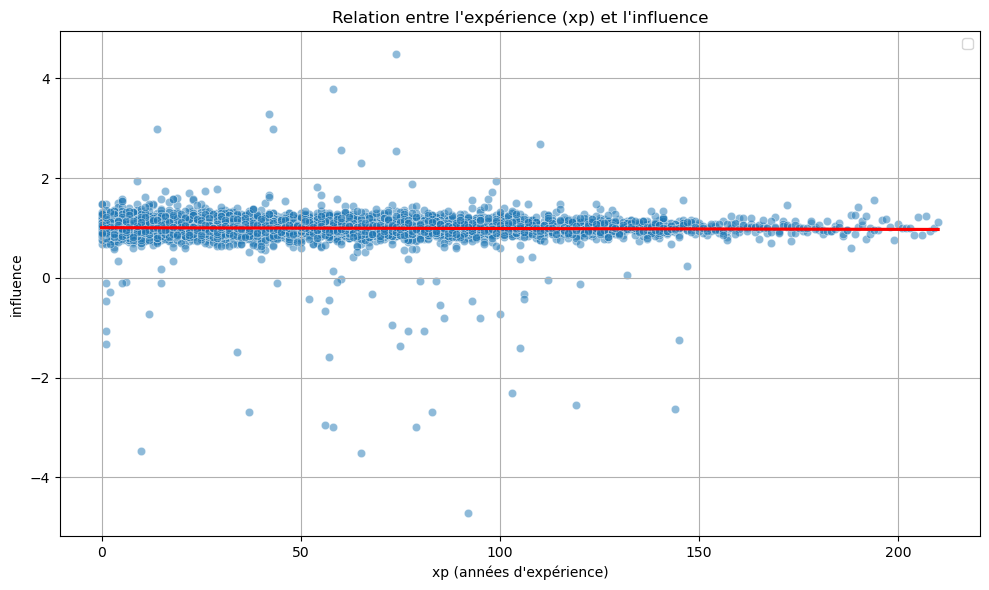

In [19]:
import seaborn as sns

df = df[(df['influence'] >= -5) & (df['influence'] <= 5)]

# Filtrer les données valides (pas de NaN dans xp et influence)
df_plot = df[['xp', 'influence']].dropna()

# Taille et style du graphique
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='xp', y='influence', alpha=0.5)

# Ajout d'une régression linéaire lissée pour voir la tendance (optionnel)
sns.regplot(data=df_plot, x='xp', y='influence', scatter=False, color='red', line_kws={'label':"Tendance (linéaire)"})

# Mise en forme
plt.title("Relation entre l'expérience (xp) et l'influence")
plt.xlabel("xp (années d'expérience)")
plt.ylabel("influence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
df['influence'].describe()

count    6420.000000
mean        0.995588
std         0.262487
min        -4.721835
25%         0.927023
50%         0.998755
75%         1.077752
max         4.480441
Name: influence, dtype: float64

In [21]:
vars_to_use = ['influence', 'xp', 'Phd', 'gender', 'bankpres']
df_reg_clean = df[vars_to_use].dropna()

X = df_reg_clean[['xp', 'Phd', 'gender', 'bankpres']]
X = sm.add_constant(X)  # Ajoute l'ordonnée à l'origine (constante)
y = df_reg_clean['influence']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              influence   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     6.105
Date:                Mon, 29 Sep 2025   Prob (F-statistic):           6.71e-05
Time:                        16:52:36   Log-Likelihood:                -545.76
No. Observations:                6271   AIC:                             1102.
Df Residuals:                    6266   BIC:                             1135.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9968      0.008    123.953      0.000       0.981       1.013
xp            -0.0002   8.67e-05     -2.496      0.013      -0.000   -4.64e-05
Phd           -0.0161      0.007     -2.302      0.021      -0.030      -0.002
gender         0.0064      0.010      0.627      0.531      -0.014       0.026
bankpres       0.0276      0.007      3.712      0.000       0.013       0.042
==============================================================================
Omnibus:                     8395.249   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          4483322.394
Skew:                          -7.231   Prob(JB):                         0.00
Kurtosis:                     133.189   Cond. No.                         216.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## partie 3 : MESURE DE DIVERSITE

In [22]:
chemin_econo=("donnees/df_econometrie.csv")
df=pd.read_csv(chemin_econo)
df['embedding'] = df['embedding'].apply(ast.literal_eval)
df

,Date,Speaker,Statement,embedding,influence,fs,bs
0,1976-03-29,MR. BALLES,"Mr. Chairman, may I respond to Governor Coldwe...","[-0.017731767147779465, -0.03243735432624817, ...",NaN,NaN,NaN
1,1976-03-29,MR. BLACK,You also have more constraint on your federal ...,"[0.08444944769144058, -0.03308793902397156, -0...",NaN,NaN,NaN
2,1976-03-29,MR. BURNS,"During our last Committee meeting, Governor Co...","[-0.05753886699676514, 0.05223332718014717, 0....",NaN,NaN,NaN
3,1976-03-29,MR. COLDWELL,"If I could, Mr. Chairman, I’d like us to retur...","[-0.02146947756409645, 0.020042279735207558, -...",NaN,NaN,NaN
4,1976-03-29,MR. EASTBURN,"Yes, a better relationship between nonborrowed...","[-0.051669877022504807, -0.031003059819340706,...",NaN,NaN,NaN
...,...,...,...,...,...,...,...
6472,2018-12-19,MS. BRAINARD,"During our meeting today, I'd like to address ...","[-0.05967159941792488, -0.0843530148267746, 0....",NaN,NaN,NaN
6473,2018-12-19,MS. DALY,"During our meeting today, I'd like to begin by...","[0.04728658124804497, -0.010734462179243565, 0...",NaN,NaN,NaN
6474,2018-12-19,MS. GEORGE,"During our meeting, I'd like to share some ins...","[-0.055877480655908585, -0.02906075119972229, ...",NaN,NaN,NaN
6475,2018-12-19,MS. LOGAN,"At the meeting today, I'd like to discuss mone...","[-0.05414874106645584, -0.029754288494586945, ...",NaN,NaN,NaN


In [24]:
stats = pd.read_stata("donnees/22juillet.dta")
stats = stats[['Date', 'Speaker', 'vote_dissent', 'q_importance', 'xp', 'bankpres', 'Phd', 'gender']]
stats = stats.sort_values(by='Date').reset_index(drop=True)
stats

,Date,Speaker,vote_dissent,q_importance,xp,bankpres,Phd,gender
0,1976-03-29,MR. HOLLAND,NaN,0.0,33,0.0,1.0,0
1,1976-03-29,MR. PARTEE,NaN,0.0,2,0.0,0.0,0
2,1976-03-29,MR. WALLICH,NaN,0.0,24,0.0,1.0,0
3,1976-03-29,MR. EASTBURN,NaN,0.0,73,1.0,1.0,0
4,1976-03-29,MR. MORRIS,NaN,0.0,96,1.0,1.0,0
...,...,...,...,...,...,...,...,...
6460,2018-12-19,MR. BARKIN,0.0,0.0,7,1.0,0.0,0
6461,2018-12-19,MS. MESTER,0.0,0.0,37,1.0,1.0,1
6462,2018-12-19,MR. CLARIDA,0.0,0.0,2,0.0,1.0,0
6463,2018-12-19,MS. DALY,0.0,0.0,1,1.0,1.0,1


In [25]:
df = df.merge(stats[['Date', 'Speaker']], on=['Date', 'Speaker'], how='inner')
df = df.merge(stats[['Date', 'Speaker', 'vote_dissent', 'q_importance', 'xp', 'bankpres', 'Phd', 'gender']], on=['Date', 'Speaker'], how='left')

In [26]:
def compute_rho_i(row, df):
    same_day_others = df[(df['Date'] == row['Date']) & (df['Speaker'] != row['Speaker'])]
    if same_day_others.empty:
        return np.nan
    sims = [cosine_sim(row['embedding'], other_emb) for other_emb in same_day_others['embedding']]
    return np.mean(sims)

In [27]:
df['rho_i'] = df.apply(lambda row: compute_rho_i(row, df), axis=1)
rho_m_per_date = df.groupby('Date')['rho_i'].mean().rename('rho_m')
df = df.merge(rho_m_per_date, on='Date', how='left')
df['rho_div'] = df['rho_m'] - df['rho_i']

In [28]:
df_reg = df[df['vote_dissent'].isin([0.0, 1.0])].copy()
df_reg

,Date,Speaker,Statement,embedding,influence,fs,bs,vote_dissent,q_importance,xp,bankpres,Phd,gender,rho_i,rho_m,rho_div
13,1976-04-20,MR. BALLES,"Mr. Chairman, I’d like to say just a few words...","[-0.03893685340881348, -0.05055658891797066, -...",1.291854,0.359127,0.277994,0.0,0.391124,42,1.0,1.0,0,0.380558,0.427335,0.046777
15,1976-04-20,MR. BLACK,I haven’t had enough mathematics to comment in...,"[-0.07298705726861954, -0.08518246561288834, 0...",1.276950,0.424892,0.332740,0.0,0.292191,32,1.0,1.0,0,0.434422,0.427335,-0.007087
16,1976-04-20,MR. BURNS,"During our discussion today, I'd like to addre...","[0.023454250767827034, -0.0014663094189018011,...",1.259337,0.485637,0.385629,0.0,0.646720,76,0.0,1.0,0,0.515247,0.427335,-0.087913
17,1976-04-20,MR. COLDWELL,"Chairperson, I believe the recovery is progres...","[0.005005501676350832, -0.07418566942214966, 0...",1.295905,0.527812,0.407292,0.0,0.476463,104,0.0,1.0,0,0.505451,0.427335,-0.078116
19,1976-04-20,MR. GARDNER,I have been impressed and pleased with the spa...,"[-0.011077809147536755, -0.08333038538694382, ...",1.336251,0.337158,0.252317,0.0,0.244914,1,0.0,0.0,0,0.339028,0.427335,0.088307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6458,2018-12-19,MR. WILLIAMS,"Mr. Chairman, I'd like to express my support f...","[-0.019636426120996475, -0.0564022995531559, -...",NaN,NaN,NaN,0.0,0.000000,67,1.0,1.0,0,0.443867,0.477371,0.033504
6459,2018-12-19,MS. BOWMAN,"Mr. Chairman, I'd like to add to the discussio...","[-0.03093745745718479, -0.08725057542324066, 0...",NaN,NaN,NaN,0.0,0.000000,0,0.0,0.0,1,0.454251,0.477371,0.023120
6460,2018-12-19,MS. BRAINARD,"During our meeting today, I'd like to address ...","[-0.05967159941792488, -0.0843530148267746, 0....",NaN,NaN,NaN,0.0,0.000000,36,0.0,1.0,1,0.555589,0.477371,-0.078218
6461,2018-12-19,MS. DALY,"During our meeting today, I'd like to begin by...","[0.04728658124804497, -0.010734462179243565, 0...",NaN,NaN,NaN,0.0,0.000000,1,1.0,1.0,1,0.353671,0.477371,0.123700


In [29]:
df_reg['rho_div'].describe()

count    3890.000000
mean        0.004062
std         0.096313
min        -0.140923
25%        -0.052801
50%        -0.016556
75%         0.030998
max         0.614291
Name: rho_div, dtype: float64

In [30]:
df_reg['vote_dissent'].value_counts()

0.0    3619
1.0     271
Name: vote_dissent, dtype: int64

In [31]:
# Définir les variables explicatives
X = df_reg[['rho_div', 'xp','Phd', 'gender', 'influence']]

# Ajouter l'intercept
X = sm.add_constant(X)

# Variable cible
y = df_reg['vote_dissent']

# Retirer les lignes avec valeurs manquantes
Xy = pd.concat([X, y], axis=1).dropna()
X = Xy.drop(columns='vote_dissent')
y = Xy['vote_dissent']

# Régression logistique
logit_model = sm.Logit(y, X).fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.251089
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           vote_dissent   No. Observations:                 3868
Model:                          Logit   Df Residuals:                     3862
Method:                           MLE   Df Model:                            5
Date:                Mon, 29 Sep 2025   Pseudo R-squ.:                 0.01068
Time:                        16:53:29   Log-Likelihood:                -971.21
converged:                       True   LL-Null:                       -981.70
Covariance Type:            nonrobust   LLR p-value:                 0.0008217
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.1462      0.175    -17.992      0.000      -3.489      -2.803
rho_div       -1.5194      0.757     -2.008      0.045      -3.002      -0.037
xp             0.0042      0.002      2.640      0.008       0.001       0.007
Phd            0.3501      0.138      2.533      0.011       0.079       0.621
gender         0.1281      0.177      0.722      0.470      -0.219       0.476
influence      0.1084      0.109      0.998      0.318      -0.104       0.321
==============================================================================
"""

In [32]:
X = df_reg[['rho_div']]
X = sm.add_constant(X)
y = df_reg['vote_dissent']
logit_model = sm.Logit(y, X).fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.252263
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           vote_dissent   No. Observations:                 3890
Model:                          Logit   Df Residuals:                     3888
Method:                           MLE   Df Model:                            1
Date:                Mon, 29 Sep 2025   Pseudo R-squ.:                0.002021
Time:                        16:53:29   Log-Likelihood:                -981.30
converged:                       True   LL-Null:                       -983.29
Covariance Type:            nonrobust   LLR p-value:                   0.04621
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5936      0.063    -41.053      0.000      -2.717      -2.470
rho_div       -1.4448      0.763     -1.893      0.058      -2.941       0.051
==============================================================================
"""